## Information


[**WiDS Global Datathon 2026**](https://www.kaggle.com/competitions/WiDSWorldWide_GlobalDathon26)

Predicting Time-to-Threat for Evacuation Zones Using Survival Analysis

**Overview**

When a wildfire ignites, emergency managers face an impossible question with incomplete information. Which fires will reach populated areas? How quickly? And which communities should prepare first?

This year's WiDS Global Datathon challenges participants to build survival models that answer these questions using only the earliest signals available. Your task is to predict the probability that a wildfire will threaten an evacuation zone within 12, 24, 48, and 72 hours, drawing on data from just the first five hours after ignition.

The goal is not a single prediction but a calibrated forecast across multiple time horizons. Emergency responders need both urgency rankings (which fires demand immediate attention) and probability estimates they can trust when making high-stakes decisions about evacuations, resource deployment, and public alerts.

**Problem**

When a wildfire starts, emergency teams must quickly decide which areas to prioritize, when to issue warnings, and how to allocate limited resources—despite uncertainty. This competition frames that challenge as a survival analysis task, where the goal is to produce well-calibrated probability predictions across different time horizons to estimate how likely fires are to threaten communities in time for action.



**Real-World Context**

Traditional wildfire prediction often focuses on a single question—whether a fire will become dangerous—but real-world response requires more nuanced, time-sensitive decisions. Teams need to know how soon a threat may occur, how confident the prediction is, and which fires should be prioritized when resources are limited.

This competition addresses that need by framing the problem as a survival analysis task using early-stage wildfire data. The dataset includes fire perimeter dynamics and distances to evacuation zones, with features derived only from the first five hours after detection (t0). The goal is to predict the time from t0 + 5 hours until the fire comes within 5 km of an evacuation zone centroid.



**Survival Analysis Framing and Censoring**

The problem is framed as a right-censored survival analysis task. If a fire reaches within 72 hours, it is labeled as an event (event = 1) with the observed time to impact. If not, it is treated as censored (event = 0) with the last observed time (up to 72 hours).

Instead of predicting a single time, participants must estimate the probability that a fire will reach an evacuation zone within specific time horizons (12h, 24h, 48h, 72h). The best models will both rank fires by urgency and provide well-calibrated probabilities to support real-world decision-making.

**Evaluation**

**Primary Metric**: `Hybrid Score = 0.3 x C-index + 0.7 x (1 - Weighted Brier Score)`

*C-index (30%)*

- Measures how well you rank fires by urgency
- Higher is better (0.5 to 1.0)

*Weighted Brier Score (70%)*

- Measures calibration at 24h, 48h, 72h
- Uses censor-aware evaluation:
  - Hits: 1 if hit by horizon H, else 0
  - Censored after H: 0
  - Censored before H: excluded
- Final weighted average: `0.3 x Brier@24h + 0.4 x Brier@48h + 0.3 x Brier@72h`

**Why 48h Is Weighted Highest**
- 24-48 hours is the strongest operational value zone
- 48h is emphasized because it balances actionable lead time with decision urgency.
- 72h is included for extended planning, but it can be less operationally immediate than earlier horizons.

**Dataset Description**

*Data Limitations and Scarcity*

This page describes the data, provided files, their formats, and the required submission format.

The dataset contains 316 wildfire events with verified early-stage perimeter observations and confirmed outcomes.

---

*What you receive*

Features computed strictly from the first five hours after initial perimeter detection. These represent early spread dynamics and spatial relationships to evacuation zones.

---

*What you predict*

Four probabilities for each fire. Each probability represents the likelihood that the fire comes within 5 km of an evacuation zone centroid by the horizon. prob_12h prob_24h prob_48h prob_72h

---

*Understanding the labels*

This is right-censored survival data. If a fire reaches an evacuation zone within 72 hours, event is 1 and time_to_hit_hours is observed. If a fire does not reach an evacuation zone within 72 hours, event is 0 and time_to_hit_hours is censored at the last available observation.

---

*Why 316 fires and not 3,000*

Most wildfires do not have both requirements needed for reliable labels. Early perimeter updates within the first five hours for feature extraction

Sufficient follow-up perimeter observations to confirm whether and when the threshold was reached. This constraint is structural, not accidental. It reflects how real incident data is collected. It also changes what good modeling looks like.

---

*This competition therefore emphasizes:*

- Survival-aware modeling
- Proper handling of censoring
- Calibration over raw accuracy

**Features**

*Identifier*

`event_id`: Anonymized fire event identifier (stable random remap, no temporal meaning)

---

*Targets (train only)*

`time_to_hit_hours`: Time from t0+5h until fire comes within 5 km of an evac zone (hours). For censored events (never hit within 72h), this is the last observed time within the window (<= 72).

`event`: Event indicator, 1 if fire hit within 72h, 0 if censored (never hit)

---

*Temporal Coverage (first 5h only)*

`num_perimeters_0_5h`: Number of perimeters within first 5 hours
dt_first_last_0_5h: Time span between first and last perimeter (hours)

`low_temporal_resolution_0_5h`: Flag, 1 if dt < 0.5h or only 1 perimeter, else 0

---

*Growth Features*

`area_first_ha`: Initial fire area at t0 (hectares)

`area_growth_abs_0_5h`: Absolute area growth (hectares)

`area_growth_rel_0_5h`: Relative area growth (fraction)

`area_growth_rate_ha_per_h`: Area growth rate (hectares/hour)

`log1p_area_first`: Log(1 + initial area)

`log1p_growth`: Log(1 + absolute growth)

`log_area_ratio_0_5h`: Log ratio of final to initial area

`relative_growth_0_5h`: Relative growth (same as area_growth_rel_0_5h)

`radial_growth_m`: Change in effective radius (meters)

`radial_growth_rate_m_per_h`: Rate of radial growth (meters/hour)

---

*Centroid Kinematics*

`centroid_displacement_m`: Total displacement of fire centroid (meters)

`centroid_speed_m_per_h`: Speed of centroid movement (meters/hour)

`spread_bearing_deg`: Bearing/direction of fire spread (degrees)

`spread_bearing_sin`: Sine of spread bearing (circular encoding)

`spread_bearing_cos`: Cosine of spread bearing (circular encoding)

---

*Distance to Evacuation Zone Centroids*

`dist_min_ci_0_5h`: Minimum distance to nearest evac zone centroid (meters)

`dist_std_ci_0_5h`: Standard deviation of distances

`dist_change_ci_0_5h`: Change in distance (d5 - d0, negative = closing)

`dist_slope_ci_0_5h`: Linear slope of distance vs time (meters/hour)

`closing_speed_m_per_h`: Speed at which fire is closing distance (m/hour, positive = closing)

`closing_speed_abs_m_per_h`: Absolute closing speed

`projected_advance_m`: Projected advance toward evac zone (d0 - d5)

`dist_accel_m_per_h2`: Acceleration in distance change (meters/hour^2)

`dist_fit_r2_0_5h`: R^2 of linear fit to distance vs time

---

*Directionality*

`alignment_cos`: Cosine of angle between fire motion and evac direction

`alignment_abs`: Absolute alignment between fire motion and evac direction (0-1, higher = more aligned)

`cross_track_component`: Sideways drift component

`along_track_speed`: Speed component toward/away from evac

---

*Temporal Metadata*

`event_start_hour`: Hour of day when fire started (0-23)

`event_start_dayofweek`: Day of week (0 = Monday, 6 = Sunday)

`event_start_month`: Month when fire started (1-12)

---

*Acronyms and Short Terms*

`t0`: Fire start time (first perimeter observation)

`5h`: Feature window length (first 5 hours after t0)

`evac`: Evacuation zone

`ci`: Centroid-to-centroid distance

## Study note

**Survival Analysis**: Dự đoán khi nào sự kiện xảy ra — không chỉ có hay không — với dữ liệu bị censored.

- Câu hỏi trung tâm: Xác suất event xảy ra trong vòng T giờ/ngày/tháng là bao nhiêu?

- Duration t: Thời gian từ lúc bắt đầu đến khi event xảy ra (hoặc hết window quan sát).

- Event indicator: 1 nếu event thực sự xảy ra. 0 nếu hết giờ mà chưa thấy (censored).

- Censoring: Không biết event có xảy ra sau window không — chỉ biết "chưa thấy trong lúc quan sát".

Khi có censored data:

- **Classification / Regression**
  - Bỏ censored → mất data, bias
  - Coi censored = "không hit" → sai, chỉ là "chưa thấy"
  - Mất thông tin về thời gian
  - 4 model riêng → có thể inconsistent nhau

- **Survival Analysis**
  - Tích hợp censored observations đúng cách
  - Học pattern theo thời gian liên tục
  - Predict toàn bộ survival curve
  - 4 probabilities luôn consistent (không tăng ngược)

**Functions**

>*Survival function S(t)*
>
> `S(t) = P(T > t)`: Xác suất event chưa xảy ra tại thời điểm t. Luôn giảm dần từ 1 → 0 theo thời gian.
>
> WiDS: `prob hit = 1 - S(t)`: `prob_12h = 1 - S(12)`, `prob_24h = 1 - S(24)`, `prob_48h = 1 - S(48)`

>*Hazard function h(t)*
>
>`h(t) = "tốc độ nguy hiểm tại t"`: Xác suất event xảy ra ngay lúc này, given rằng chưa xảy ra. Dùng để so sánh giữa groups.
>
> Hazard Ratio từ Cox model: `HR > 1` → nguy hiểm hơn, `HR < 1` → an toàn hơn, `HR = 1` → không ảnh hưởng


**Approachs**

*Kaplan-Meier — Non-parametric*: Không giả định gì, chỉ dùng data để vẽ survival curve. Dùng để visualize và so sánh groups, không predict được cho observation mới. `Trực quan` `Không cần giả định` `Không predict được`

---

*Cox Proportional Hazards — Semi-parametric*: Model phổ biến nhất. Học effect của từng feature lên hazard. Cho biết feature nào quan trọng và theo hướng nào (Hazard Ratio). `h(t|X) = h₀(t) × exp(β₁X₁ + β₂X₂ + ...)`. `Dễ interpret` `Predict được` `Giả định proportional hazards`

---

*Survival Forest / DeepSurv — ML*: Không cần giả định proportional hazards, bắt được non-linear patterns. Thường cho kết quả tốt nhất trong competitions nhưng khó interpret hơn. `Non-linear` `Không cần giả định` `Cần nhiều data hơn`

**Evaluation metrics**

*C-index*: `0.5–1.0` - Ranking đúng bao nhiêu % cặp? `0.5` = random, `1.0` = perfect

*Brier Score*: `↓ thấp hơn` - Calibration: xác suất dự đoán có khớp thực tế? `0` = perfect, `0.25` = random

*WiDS Hybrid*: `0.3 × C-index + 0.7 × (1 − Brier)` - Nhấn mạnh calibration hơn ranking

`time_to_hit_hours`: Duration — label của model, không phải feature. Là T thực nếu hit, T cuối quan sát nếu censored.

`event`: Event indicator — `1` nếu hit trong 72h, `0` nếu censored. Cùng với `time_to_hit_hours` tạo thành survival label.

`prob_12/24/48/72h`: `Output = 1 − S(t)` tại 4 mốc. Predict 1 survival curve, sample tại 4 điểm. Không cần 4 model riêng.

**Chỉ 316 fires**: Dataset nhỏ → tránh overfitting. Ưu tiên `Cox` hoặc `Survival Forest` với regularization mạnh.

## EDA

In [ ]:
!pip -q install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.8 MB/s eta 0:00:00


In [ ]:
# Load the datasets
from pathlib import Path
DATA_DIR = Path(".")

import pandas as pd
train_raw = pd.read_csv(DATA_DIR / "train.csv")
test_raw = pd.read_csv(DATA_DIR / "test.csv")

# Calculate some basic statistics
n_hits = int(train_raw['event'].sum())
n_censored = len(train_raw) - n_hits
hit_times = train_raw.loc[train_raw['event'] == 1, 'time_to_hit_hours']

# Print a summary
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Training set:   {train_raw.shape[0]} fires with {train_raw.shape[1]} columns")
print(f"Test set:       {test_raw.shape[0]} fires with {test_raw.shape[1]} columns")
print()
print("Target distribution in training data:")
print(f"  Fires that HIT:        {n_hits} ({n_hits/len(train_raw)*100:.1f}%)")
print(f"  Censored (no hit):     {n_censored} ({n_censored/len(train_raw)*100:.1f}%)")
print()
print("Time to hit (for fires that hit):")
print(f"  Average: {hit_times.mean():.1f} hours")
print(f"  Median:  {hit_times.median():.1f} hours")
print(f"  Fastest: {hit_times.min():.2f} hours")
print(f"  Slowest: {hit_times.max():.1f} hours")
print()
print(f"Missing values: {train_raw.isnull().sum().sum()}")
print("=" * 60)

print("First 5 rows of training data:")
print()
train_raw.head()

DATASET SUMMARY
Training set:   221 fires with 37 columns
Test set:       95 fires with 35 columns

Target distribution in training data:
  Fires that HIT:        69 (31.2%)
  Censored (no hit):     152 (68.8%)

Time to hit (for fires that hit):
  Average: 10.0 hours
  Median:  3.5 hours
  Fastest: 0.00 hours
  Slowest: 66.9 hours

Missing values: 0
First 5 rows of training data:



,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


Configuration complete!


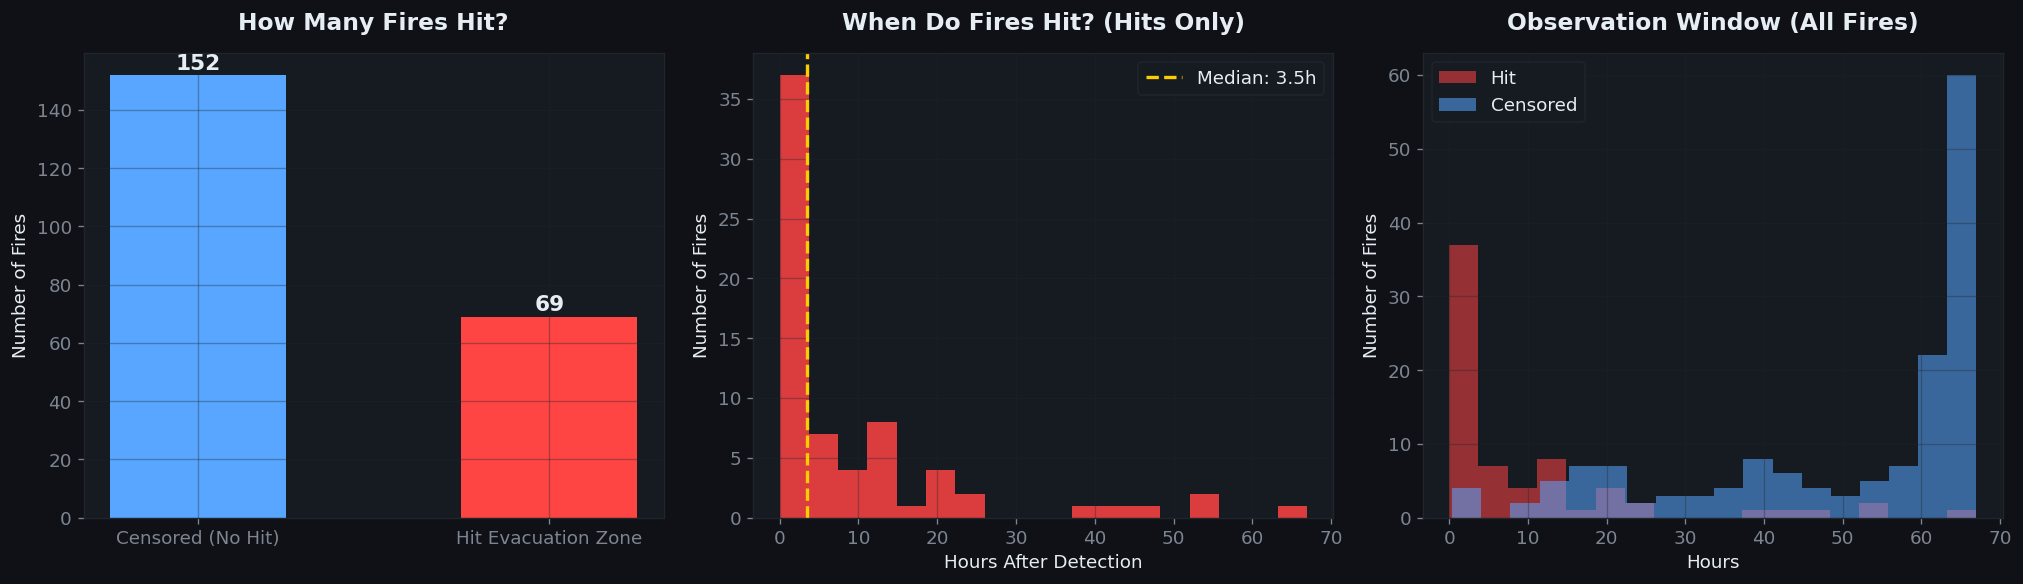

Key Insight: Most fires that hit do so within the first 20 hours!
  50% of hits occur within 3.5 hours
  75% of hits occur within 14.3 hours


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Colors that work well on both dark and light backgrounds
BACKGROUND = '#0f1117'
CARD_BG = '#161b22'
TEXT_COLOR = '#e6edf3'
MUTED_COLOR = '#7d8590'
GRID_COLOR = '#21262d'

# Fire-themed colors for our charts
FIRE_COLORS = ['#ff6b35', '#ff3333', '#ffcc02', '#ff8c42']
HIT_COLOR = '#ff4444'      # Red for fires that hit
MISS_COLOR = '#58a6ff'     # Blue for fires that missed
SAFE_COLOR = '#3fb950'     # Green for safe zones

# Apply the style to all charts
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'figure.dpi': 120,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': CARD_BG,
    'axes.edgecolor': GRID_COLOR,
    'axes.labelcolor': TEXT_COLOR,
    'axes.titlepad': 14,
    'text.color': TEXT_COLOR,
    'xtick.color': MUTED_COLOR,
    'ytick.color': MUTED_COLOR,
    'grid.color': GRID_COLOR,
    'grid.alpha': 0.35,
    'axes.grid': True,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'legend.facecolor': CARD_BG,
    'legend.edgecolor': GRID_COLOR,
})

print("Configuration complete!")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Chart 1: Event distribution (hit vs censored)
counts = train_raw['event'].value_counts().sort_index()
bars = axes[0].bar(
    ['Censored (No Hit)', 'Hit Evacuation Zone'],
    counts.values,
    color=[MISS_COLOR, HIT_COLOR],
    edgecolor='none',
    width=0.5
)

# Add count labels on bars
for bar, count in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        count + 2,
        str(count),
        ha='center',
        color=TEXT_COLOR,
        fontweight='bold',
        fontsize=13
    )

axes[0].set_title('How Many Fires Hit?')
axes[0].set_ylabel('Number of Fires')

# Chart 2: Time to hit distribution (hits only)
hits = train_raw[train_raw['event'] == 1]['time_to_hit_hours']
axes[1].hist(hits, bins=18, color=HIT_COLOR, alpha=0.85, edgecolor='none')
axes[1].axvline(
    hits.median(),
    color=FIRE_COLORS[2],
    ls='--',
    lw=2,
    label=f'Median: {hits.median():.1f}h'
)
axes[1].set_title('When Do Fires Hit? (Hits Only)')
axes[1].set_xlabel('Hours After Detection')
axes[1].set_ylabel('Number of Fires')
axes[1].legend()

# Chart 3: Observation window for all fires
for label, color, mask in [
    ('Hit', HIT_COLOR, train_raw['event'] == 1),
    ('Censored', MISS_COLOR, train_raw['event'] == 0)
]:
    axes[2].hist(
        train_raw.loc[mask, 'time_to_hit_hours'],
        bins=18,
        alpha=0.55,
        color=color,
        label=label,
        edgecolor='none'
    )

axes[2].set_title('Observation Window (All Fires)')
axes[2].set_xlabel('Hours')
axes[2].set_ylabel('Number of Fires')
axes[2].legend()

plt.tight_layout()
plt.show()

print("Key Insight: Most fires that hit do so within the first 20 hours!")
print(f"  50% of hits occur within {hits.median():.1f} hours")
print(f"  75% of hits occur within {hits.quantile(0.75):.1f} hours")

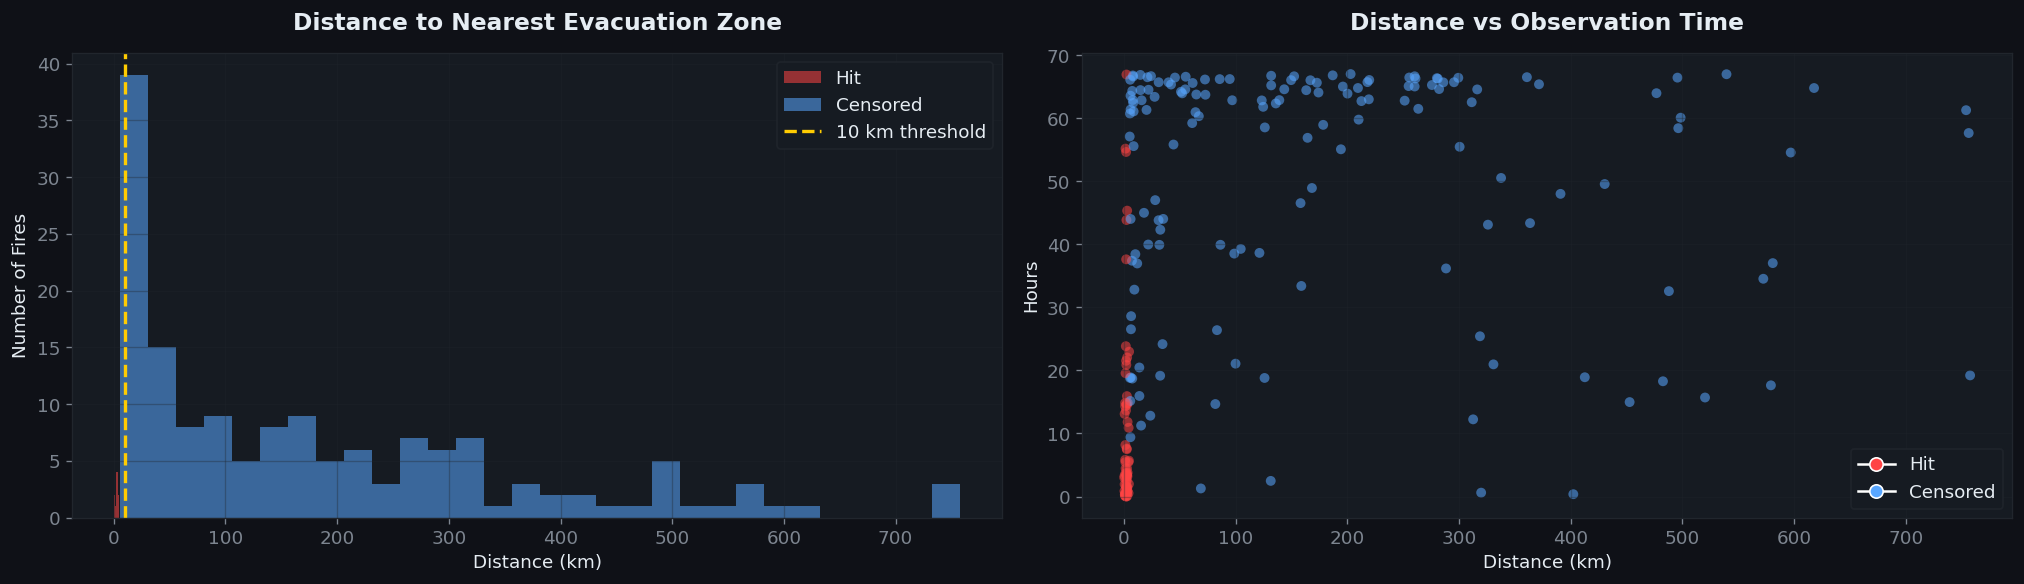

Distance Statistics:
  Fires that HIT:      avg 2.3 km, max 4.7 km
  Fires that MISSED:   avg 179.8 km, max 757.7 km

Critical finding: 0 fires beyond 10 km ever hit!
This tells us distance is incredibly predictive.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Chart 1: Distance distribution by outcome
for label, color, mask in [
    ('Hit', HIT_COLOR, train_raw['event'] == 1),
    ('Censored', MISS_COLOR, train_raw['event'] == 0)
]:
    # Convert meters to kilometers for readability
    km = train_raw.loc[mask, 'dist_min_ci_0_5h'] / 1000
    axes[0].hist(km, bins=30, alpha=0.55, color=color, label=label, edgecolor='none')

# Mark the 10km threshold
axes[0].axvline(10, color=FIRE_COLORS[2], ls='--', lw=2, label='10 km threshold')
axes[0].set_title('Distance to Nearest Evacuation Zone')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Number of Fires')
axes[0].legend()

# Chart 2: Scatter plot of distance vs time
colors = train_raw['event'].map({1: HIT_COLOR, 0: MISS_COLOR})
axes[1].scatter(
    train_raw['dist_min_ci_0_5h'] / 1000,
    train_raw['time_to_hit_hours'],
    c=colors,
    alpha=0.55,
    s=35,
    edgecolors='none'
)

axes[1].set_title('Distance vs Observation Time')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Hours')

# Add legend manually
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=HIT_COLOR, markersize=8, label='Hit'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=MISS_COLOR, markersize=8, label='Censored')
]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

# Print statistics
hit_dist = train_raw.loc[train_raw['event'] == 1, 'dist_min_ci_0_5h']
miss_dist = train_raw.loc[train_raw['event'] == 0, 'dist_min_ci_0_5h']

print("Distance Statistics:")
print(f"  Fires that HIT:      avg {hit_dist.mean()/1000:.1f} km, max {hit_dist.max()/1000:.1f} km")
print(f"  Fires that MISSED:   avg {miss_dist.mean()/1000:.1f} km, max {miss_dist.max()/1000:.1f} km")
print()
print(f"Critical finding: {(hit_dist > 10000).sum()} fires beyond 10 km ever hit!")
print("This tells us distance is incredibly predictive.")

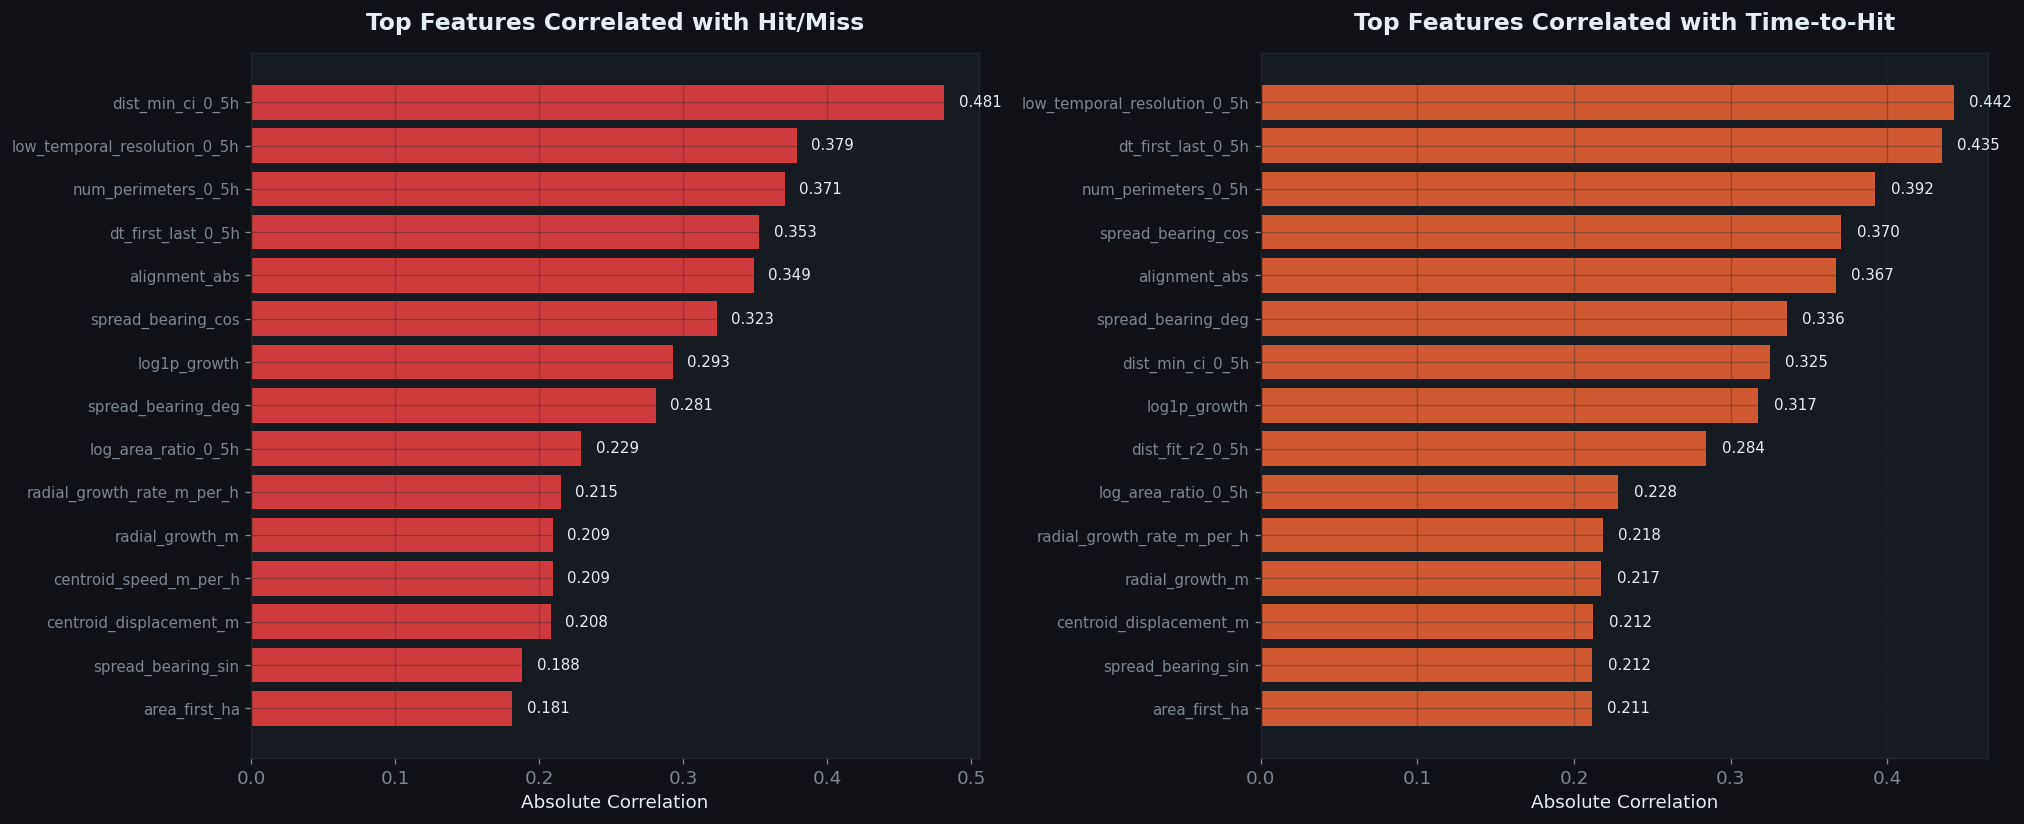

Top 5 most predictive features:
  1. dist_min_ci_0_5h: 0.481
  2. low_temporal_resolution_0_5h: 0.379
  3. num_perimeters_0_5h: 0.371
  4. dt_first_last_0_5h: 0.353
  5. alignment_abs: 0.349


In [ ]:
# Get all feature columns (exclude IDs and targets)
feature_cols = [c for c in train_raw.columns
                if c not in ['event_id', 'event', 'time_to_hit_hours']]

# Calculate correlations
corr_with_event = train_raw[feature_cols].corrwith(train_raw['event']).abs()
corr_with_time = train_raw[feature_cols].corrwith(train_raw['time_to_hit_hours']).abs()

# Sort by correlation strength
corr_with_event = corr_with_event.sort_values(ascending=False)
corr_with_time = corr_with_time.sort_values(ascending=False)

# Plot top 15 features for each target
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
top_n = 15

# Left plot: correlation with event
top_event = corr_with_event.head(top_n)
axes[0].barh(range(len(top_event)), top_event.values, color=HIT_COLOR, alpha=0.8, edgecolor='none')
axes[0].set_yticks(range(len(top_event)))
axes[0].set_yticklabels(top_event.index, fontsize=9)
axes[0].set_title('Top Features Correlated with Hit/Miss')
axes[0].set_xlabel('Absolute Correlation')
axes[0].invert_yaxis()

# Add correlation values as text
for i, v in enumerate(top_event.values):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', color=TEXT_COLOR, fontsize=9)

# Right plot: correlation with time
top_time = corr_with_time.head(top_n)
axes[1].barh(range(len(top_time)), top_time.values, color=FIRE_COLORS[0], alpha=0.8, edgecolor='none')
axes[1].set_yticks(range(len(top_time)))
axes[1].set_yticklabels(top_time.index, fontsize=9)
axes[1].set_title('Top Features Correlated with Time-to-Hit')
axes[1].set_xlabel('Absolute Correlation')
axes[1].invert_yaxis()

for i, v in enumerate(top_time.values):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', color=TEXT_COLOR, fontsize=9)

plt.tight_layout()
plt.show()

print("Top 5 most predictive features:")
for i, (feat, corr) in enumerate(corr_with_event.head(5).items(), 1):
    print(f"  {i}. {feat}: {corr:.3f}")

---
**Kaplan-Meier Curve**

*Kaplan-Meier (KM) là gì?*: Trong survival analysis, câu hỏi trung tâm không phải là "đám cháy có lan tới khu dân cư không?" mà là **"xác suất đám cháy chưa lan tới khu dân cư sau X giờ là bao nhiêu?"**

Đường KM (còn gọi là *survival curve*) trả lời đúng câu hỏi đó:
- Trục Y: Xác suất "sống sót" — tức là đám cháy **chưa** chạm tới evac zone
- Trục X: Thời gian (giờ)
- Đường càng dốc → đám cháy lan rất nhanh trong khung giờ đó
- Phần cuối đường (plateau) là các đám cháy bị **censored** (không hit trong 72h)

Khác với histogram đơn thuần, KM xử lý đúng censored observations — không bỏ qua chúng, cũng không coi chúng như "hit ở giờ cuối".

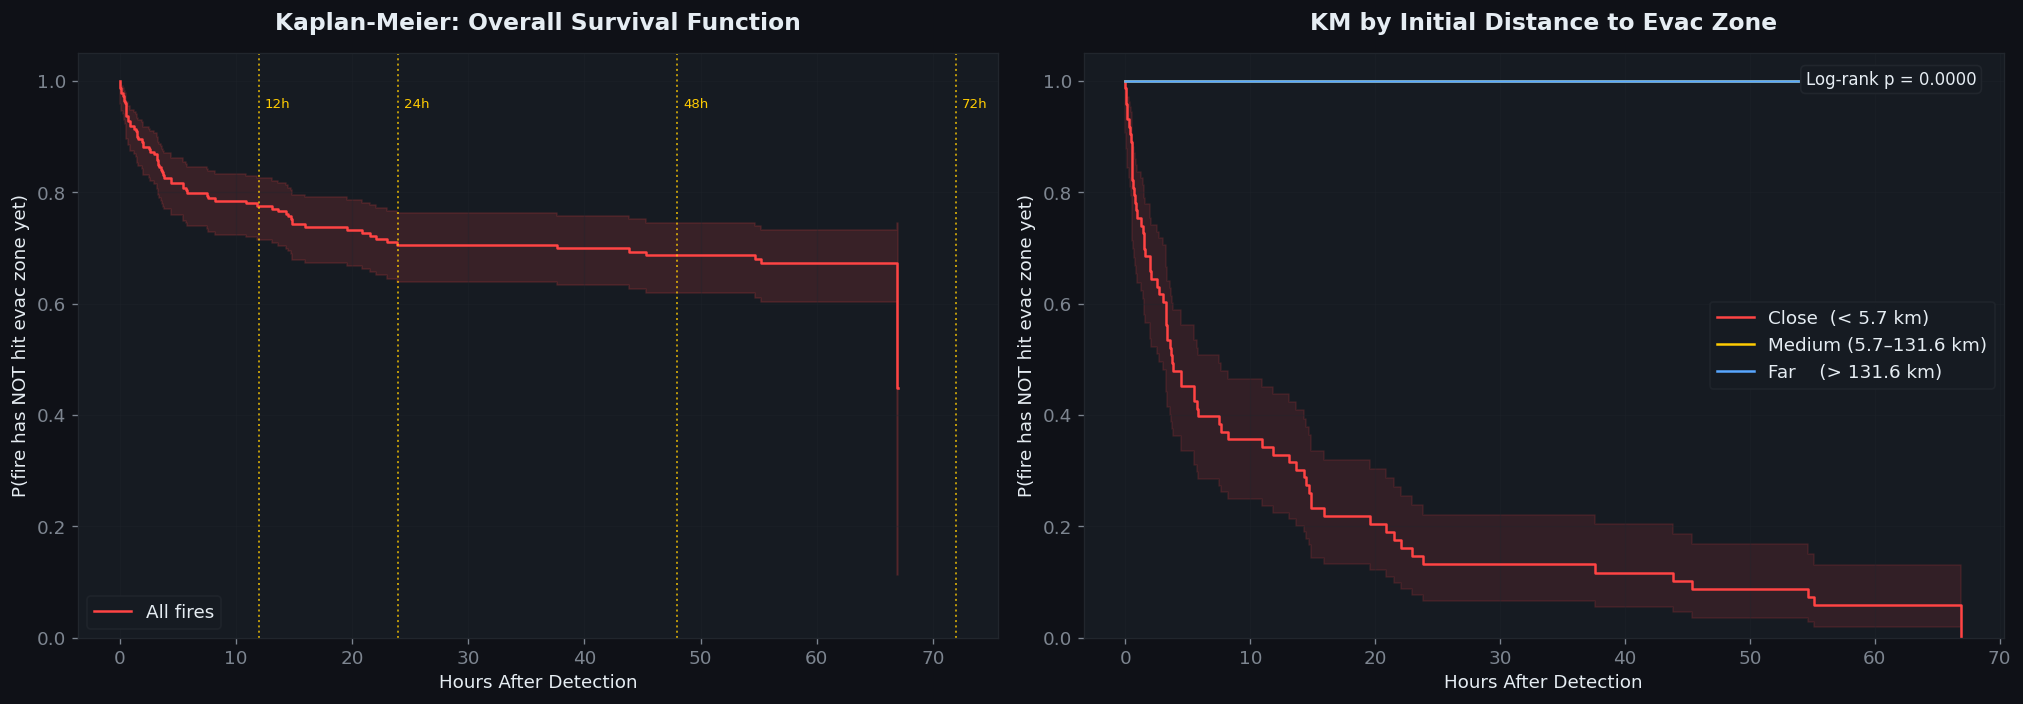

Xác suất đám cháy CHƯA hit evac zone tại mỗi mốc thời gian:
  12h: 77.5% fires vẫn chưa hit  →  22.5% fires đã hit
  24h: 70.6% fires vẫn chưa hit  →  29.4% fires đã hit
  48h: 68.7% fires vẫn chưa hit  →  31.3% fires đã hit
  72h: 44.8% fires vẫn chưa hit  →  55.2% fires đã hit


In [ ]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# ── Chart 1: Overall KM Curve ────────────────────────────────────────────────
kmf_all = KaplanMeierFitter()
kmf_all.fit(
    train_raw['time_to_hit_hours'],
    event_observed=train_raw['event'],
    label='All fires'
)
kmf_all.plot_survival_function(
    ax=axes[0],
    color=HIT_COLOR,
    ci_show=True,
    ci_alpha=0.15
)

# Mark the 4 prediction horizons
for h, label in [(12, '12h'), (24, '24h'), (48, '48h'), (72, '72h')]:
    axes[0].axvline(h, color=FIRE_COLORS[2], ls=':', lw=1.2, alpha=0.7)
    axes[0].text(h + 0.5, 0.97, label, color=FIRE_COLORS[2], fontsize=8, va='top')

axes[0].set_title('Kaplan-Meier: Overall Survival Function')
axes[0].set_xlabel('Hours After Detection')
axes[0].set_ylabel('P(fire has NOT hit evac zone yet)')
axes[0].set_ylim(0, 1.05)

# ── Chart 2: KM stratified by initial distance ───────────────────────────────
dist_33 = train_raw['dist_min_ci_0_5h'].quantile(0.33)
dist_66 = train_raw['dist_min_ci_0_5h'].quantile(0.66)

groups = {
    f'Close  (< {dist_33/1000:.1f} km)' : train_raw['dist_min_ci_0_5h'] <= dist_33,
    f'Medium ({dist_33/1000:.1f}–{dist_66/1000:.1f} km)': (train_raw['dist_min_ci_0_5h'] > dist_33) & (train_raw['dist_min_ci_0_5h'] <= dist_66),
    f'Far    (> {dist_66/1000:.1f} km)' : train_raw['dist_min_ci_0_5h'] > dist_66,
}
group_colors = [HIT_COLOR, FIRE_COLORS[2], MISS_COLOR]

for (label, mask), color in zip(groups.items(), group_colors):
    sub = train_raw[mask]
    kmf = KaplanMeierFitter()
    kmf.fit(sub['time_to_hit_hours'], event_observed=sub['event'], label=label)
    kmf.plot_survival_function(ax=axes[1], color=color, ci_show=True, ci_alpha=0.12)

# Log-rank test between Close vs Far
close = train_raw[groups[list(groups.keys())[0]]]
far   = train_raw[groups[list(groups.keys())[2]]]
lr = logrank_test(
    close['time_to_hit_hours'], far['time_to_hit_hours'],
    event_observed_A=close['event'], event_observed_B=far['event']
)

axes[1].set_title('KM by Initial Distance to Evac Zone')
axes[1].set_xlabel('Hours After Detection')
axes[1].set_ylabel('P(fire has NOT hit evac zone yet)')
axes[1].set_ylim(0, 1.05)
axes[1].text(
    0.97, 0.97,
    f'Log-rank p = {lr.p_value:.4f}',
    transform=axes[1].transAxes,
    ha='right', va='top',
    color=TEXT_COLOR, fontsize=10,
    bbox=dict(boxstyle='round,pad=0.3', facecolor=CARD_BG, edgecolor=GRID_COLOR)
)

plt.tight_layout()
plt.show()

# Print survival probabilities at each horizon
print("Xác suất đám cháy CHƯA hit evac zone tại mỗi mốc thời gian:")
for h in [12, 24, 48, 72]:
    sf = kmf_all.survival_function_at_times(h).values[0]
    print(f"  {h:2d}h: {sf:.1%} fires vẫn chưa hit  →  {1-sf:.1%} fires đã hit")

---
**2. Log-rank Test + Cox Univariate — Thay thế Correlation**

*Tại sao không dùng `corrwith()` cho survival data?*: Khi ta tính `corr(feature, time_to_hit_hours)`, các đám cháy **censored** bị coi như thật sự dừng ở thời điểm quan sát cuối. Điều này sai — chúng ta không biết thực tế chúng dừng lúc nào, chỉ biết chúng chưa hit trong window 72h.

Hai công cụ đúng:

| Công cụ | Dùng khi nào | Trả về gì |
|---|---|---|
| **Log-rank test** | Feature phân loại / chia nhóm | p-value: groups có survival khác nhau không? |
| **Cox univariate** | Feature liên tục | Hazard Ratio: mỗi 1 SD tăng → nguy cơ tăng/giảm bao nhiêu? |

**Hazard Ratio (HR) là gì?**
- HR > 1: Feature tăng → đám cháy lan nhanh hơn (nguy hiểm hơn)
- HR < 1: Feature tăng → đám cháy lan chậm hơn (an toàn hơn)
- HR = 1: Feature không có tác động

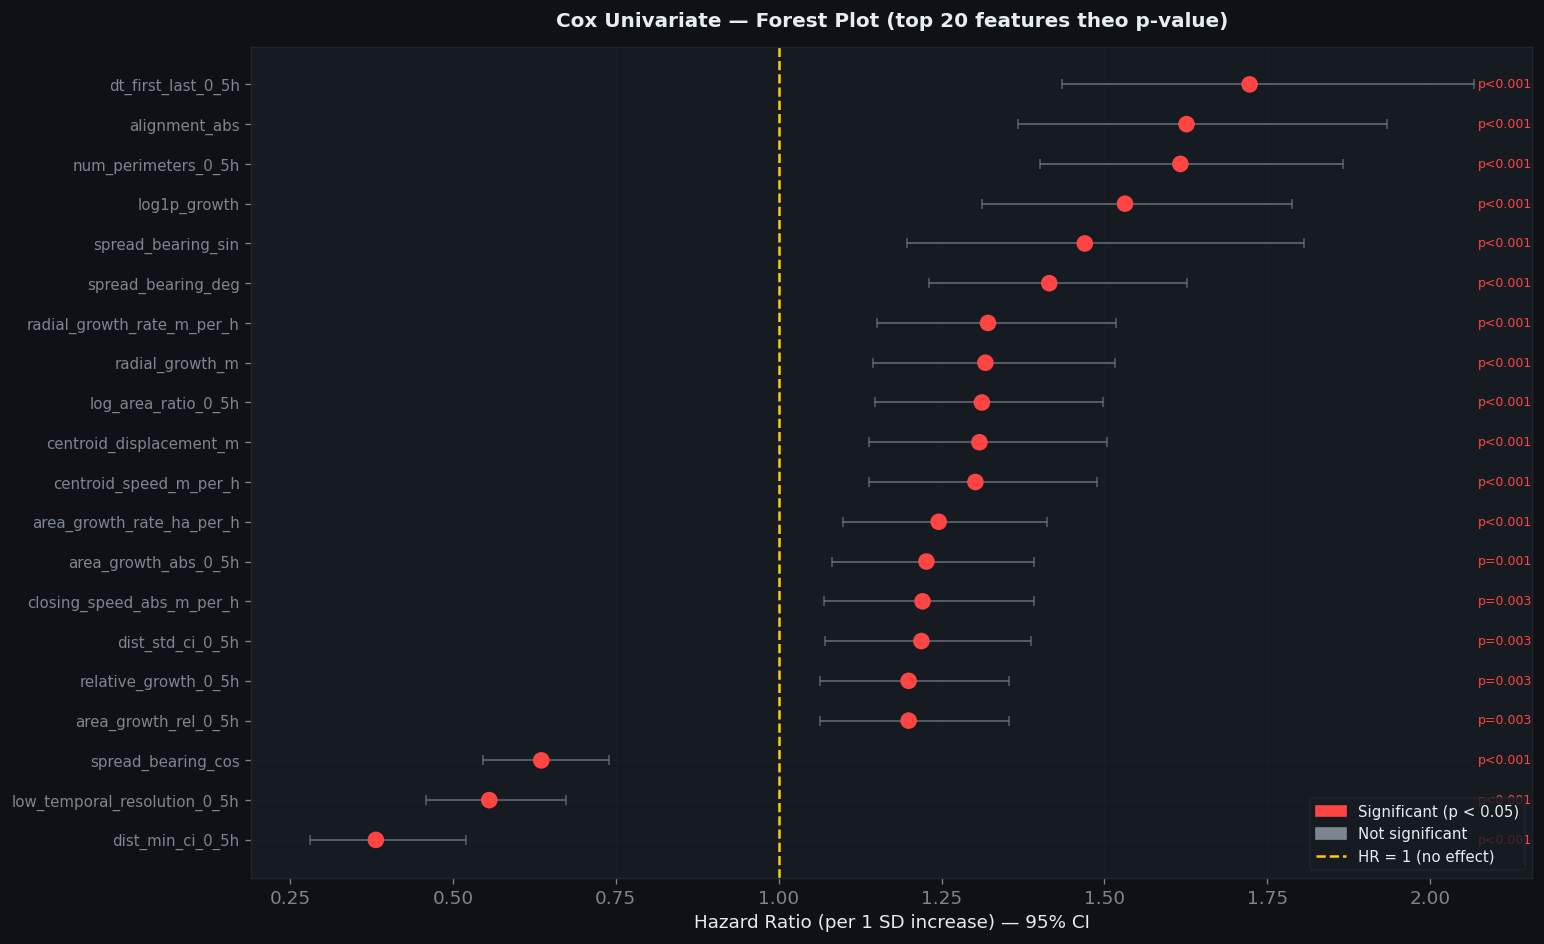


Top 10 features có p-value thấp nhất (univariate Cox):
                     feature  hazard_ratio   ci_low  ci_high      p_value  significant
         num_perimeters_0_5h      1.616482 1.400620 1.865612 5.138273e-11         True
            dist_min_ci_0_5h      0.381825 0.280173 0.520358 1.087722e-09         True
low_temporal_resolution_0_5h      0.555863 0.458831 0.673415 1.978627e-09         True
          spread_bearing_cos      0.635699 0.546956 0.738841 3.517964e-09         True
          dt_first_last_0_5h      1.722741 1.435526 2.067420 5.063148e-09         True
               alignment_abs      1.625947 1.367640 1.933039 3.651308e-08         True
                log1p_growth      1.531531 1.312303 1.787383 6.369427e-08         True
          spread_bearing_deg      1.415274 1.231333 1.626693 1.011075e-06         True
         log_area_ratio_0_5h      1.311846 1.148452 1.498486 6.349812e-05         True
  radial_growth_rate_m_per_h      1.321200 1.150597 1.517100 7.861924e-05 

In [ ]:
from lifelines import CoxPHFitter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Univariate Cox fits ───────────────────────────────────────────────────────
feature_cols = [c for c in train_raw.columns
                if c not in ['event_id', 'event', 'time_to_hit_hours']]

results = []
for feat in feature_cols:
    df_cox = train_raw[['time_to_hit_hours', 'event', feat]].copy().dropna()
    std = df_cox[feat].std()
    if std == 0:
        continue
    df_cox[feat] = (df_cox[feat] - df_cox[feat].mean()) / std
    try:
        cph = CoxPHFitter(penalizer=0.1)   # guards against separation
        cph.fit(df_cox, duration_col='time_to_hit_hours',
                event_col='event', show_progress=False)
        hr       = cph.hazard_ratios_[feat]
        p        = cph.summary['p'][feat]
        ci_low   = np.exp(cph.summary['coef lower 95%'][feat])
        ci_high  = np.exp(cph.summary['coef upper 95%'][feat])
        results.append({
            'feature':       feat,
            'hazard_ratio':  hr,
            'ci_low':        ci_low,
            'ci_high':       ci_high,
            'p_value':       p,
            'significant':   p < 0.05,
        })
    except Exception:
        pass

cox_df = pd.DataFrame(results).sort_values('p_value')

# ── Forest plot — top 20 ──────────────────────────────────────────────────────
top   = cox_df.head(20).sort_values('hazard_ratio').reset_index(drop=True)
y_pos = range(len(top))

colors = [HIT_COLOR if sig else MUTED_COLOR for sig in top['significant']]

fig, ax = plt.subplots(figsize=(13, 8))

# CI whiskers
xerr_low  = (top['hazard_ratio'] - top['ci_low']).clip(lower=0)
xerr_high = (top['ci_high'] - top['hazard_ratio']).clip(lower=0)
ax.errorbar(
    top['hazard_ratio'], y_pos,
    xerr=[xerr_low, xerr_high],
    fmt='none', color=MUTED_COLOR, capsize=3, lw=1.2, alpha=0.6,
)

# Points
ax.scatter(top['hazard_ratio'], y_pos, color=colors, s=80, zorder=3)

# Reference line
ax.axvline(1, color=FIRE_COLORS[2], ls='--', lw=1.5)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(top['feature'], fontsize=9)
ax.set_xlabel('Hazard Ratio (per 1 SD increase) — 95% CI')
ax.set_title(
    'Cox Univariate — Forest Plot (top 20 features theo p-value)',
    fontsize=12, pad=12,
)

# ── Legend via patches (avoids emoji font issues) ────────────────────────────
sig_patch  = mpatches.Patch(color=HIT_COLOR,   label='Significant (p < 0.05)')
ns_patch   = mpatches.Patch(color=MUTED_COLOR, label='Not significant')
ref_line   = plt.Line2D([0], [0], color=FIRE_COLORS[2], ls='--', lw=1.5,
                        label='HR = 1 (no effect)')
ax.legend(handles=[sig_patch, ns_patch, ref_line], loc='lower right', fontsize=9)

# ── p-value annotations (right-aligned to axes, not data coords) ─────────────
ax.figure.canvas.draw()                          # needed to lock in xlim
x_max = ax.get_xlim()[1]
for i, row in top.iterrows():
    label = 'p<0.001' if row['p_value'] < 0.001 else f"p={row['p_value']:.3f}"
    ax.text(
        x_max, i, label,
        va='center', ha='right', fontsize=7.5,
        color=HIT_COLOR if row['significant'] else MUTED_COLOR,
    )

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\nTop 10 features có p-value thấp nhất (univariate Cox):")
print(
    cox_df[['feature', 'hazard_ratio', 'ci_low', 'ci_high', 'p_value', 'significant']]
    .head(10)
    .to_string(index=False)
)

---
**3. Box Plots / Violin Plots — Feature Distribution by Outcome**

*Tại sao cần phần này?*: Correlation cho 1 con số tổng hợp, nhưng không cho thấy **hình dạng** của distribution. Hai features có cùng correlation có thể có pattern hoàn toàn khác nhau:
- Feature A: hit và censored overlap nhiều → feature yếu
- Feature B: hit và censored tách biệt rõ → feature mạnh dù cùng correlation

**Violin plot** = Histogram xoay ngang, phản chiếu 2 bên. Cho thấy cả shape lẫn median của distribution.

Ta sẽ xem các feature quan trọng nhất từ Cox analysis:

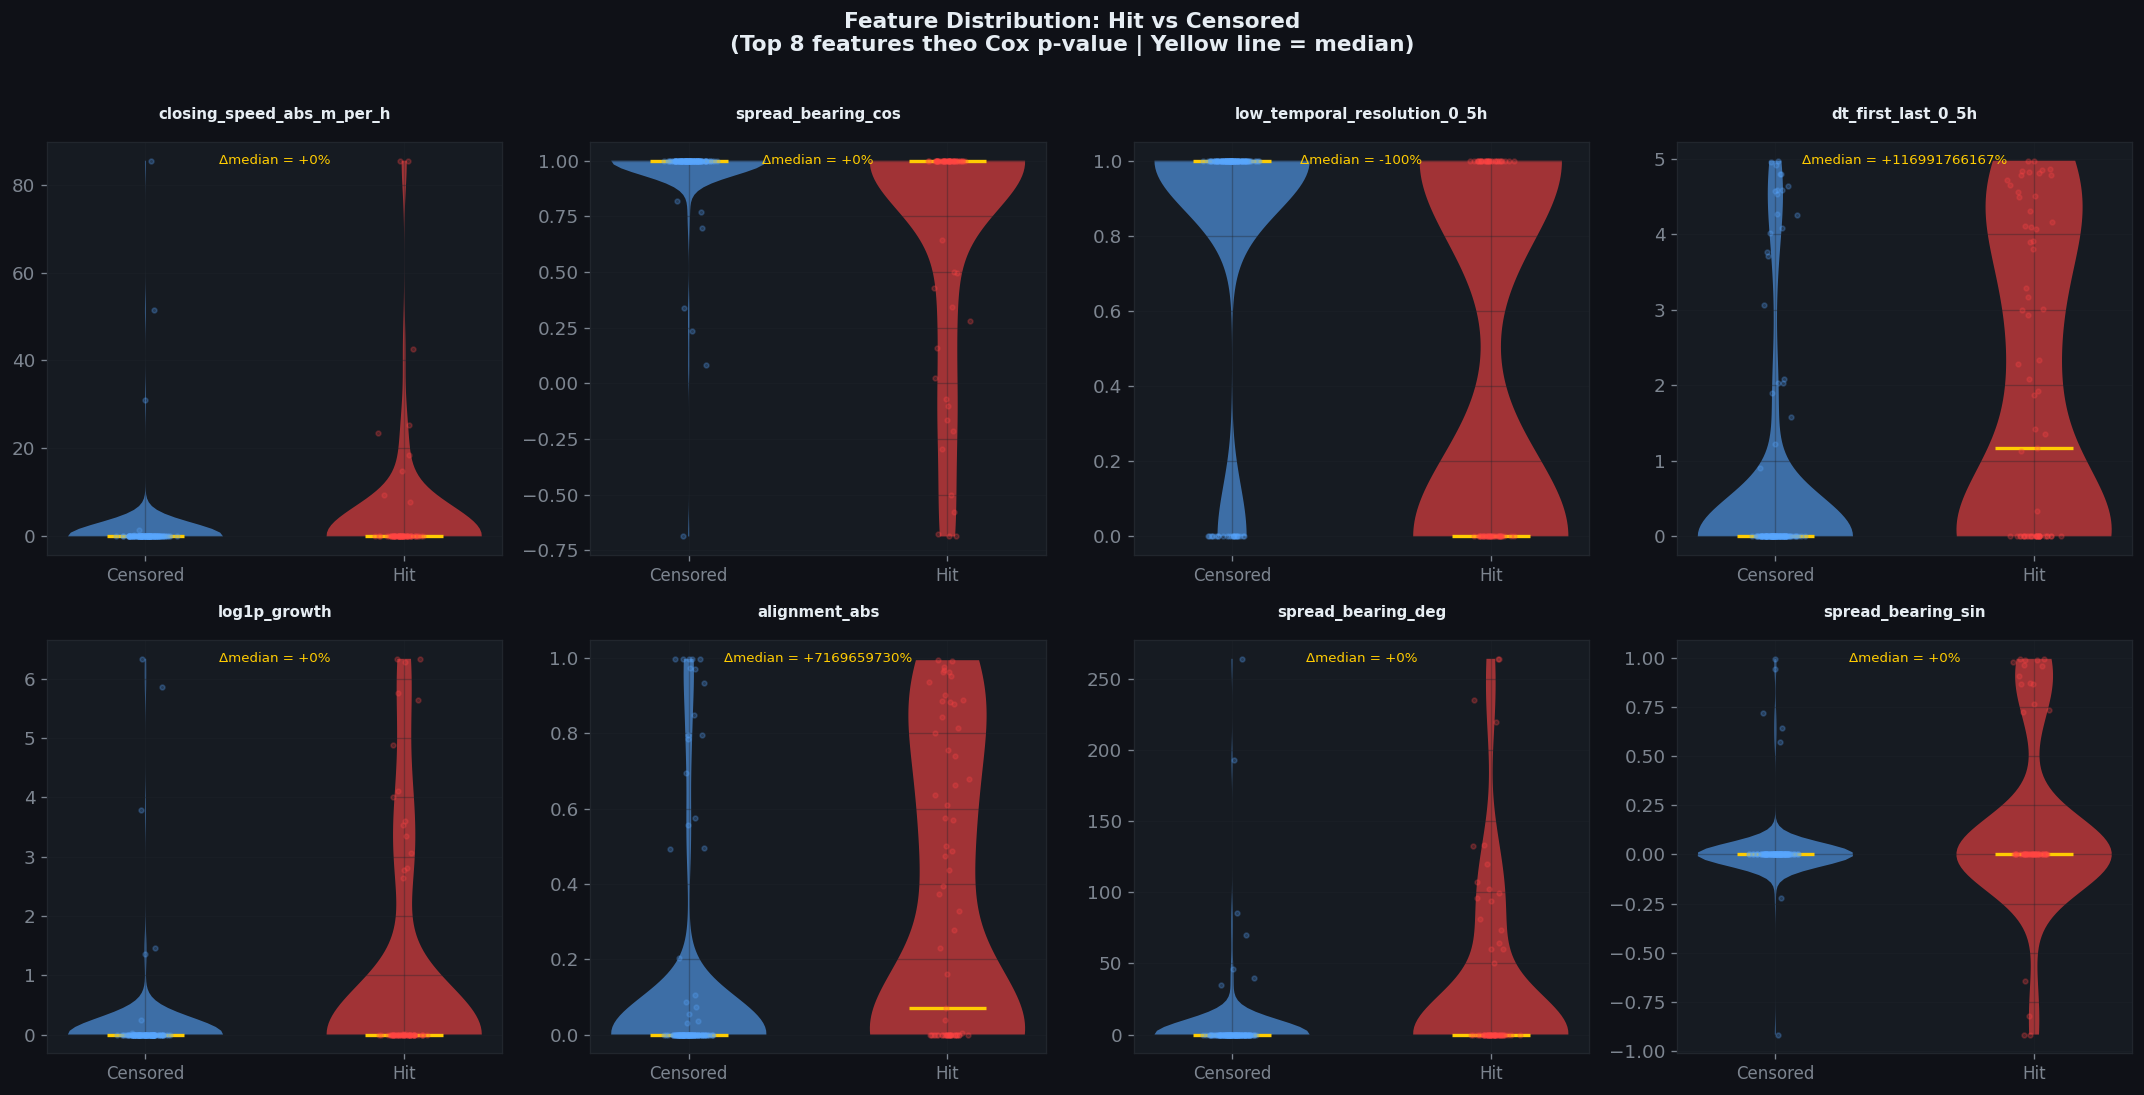

Cách đọc violin plot:
  - Violin rộng ở đâu → nhiều fires có giá trị đó
  - Đường vàng = median
  - Nếu 2 violin tách biệt rõ → feature có sức phân biệt tốt
  - Nếu 2 violin overlap nhiều → feature yếu với target này


In [ ]:
# Pick top significant features from Cox (or top by p-value if none significant)
top_features = cox_df.head(8)['feature'].tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

hit_data  = train_raw[train_raw['event'] == 1]
miss_data = train_raw[train_raw['event'] == 0]

for i, feat in enumerate(top_features):
    ax = axes[i]

    # Clip outliers for readability (1st–99th percentile)
    lo = train_raw[feat].quantile(0.01)
    hi = train_raw[feat].quantile(0.99)
    g0 = miss_data[feat].clip(lo, hi).dropna()
    g1 = hit_data[feat].clip(lo, hi).dropna()

    # Violin
    parts = ax.violinplot(
        [g0.values, g1.values],
        positions=[0, 1],
        showmedians=True,
        showextrema=False,
        widths=0.6
    )
    for pc, color in zip(parts['bodies'], [MISS_COLOR, HIT_COLOR]):
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
    parts['cmedians'].set_color(FIRE_COLORS[2])
    parts['cmedians'].set_linewidth(2)

    # Scatter (jittered)
    for j, (grp, color) in enumerate([(g0, MISS_COLOR), (g1, HIT_COLOR)]):
        jitter = np.random.normal(0, 0.04, size=len(grp))
        ax.scatter(j + jitter, grp.values, alpha=0.25, s=8, color=color, zorder=2)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Censored', 'Hit'], fontsize=10)
    ax.set_title(feat, fontsize=9, fontweight='bold')

    # Annotate median difference
    diff_pct = (g1.median() - g0.median()) / (abs(g0.median()) + 1e-9) * 100
    ax.text(
        0.5, 0.97,
        f'Δmedian = {diff_pct:+.0f}%',
        transform=ax.transAxes,
        ha='center', va='top',
        fontsize=8, color=FIRE_COLORS[2]
    )

fig.suptitle(
    'Feature Distribution: Hit vs Censored\n'
    '(Top 8 features theo Cox p-value | Yellow line = median)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

print("Cách đọc violin plot:")
print("  - Violin rộng ở đâu → nhiều fires có giá trị đó")
print("  - Đường vàng = median")
print("  - Nếu 2 violin tách biệt rõ → feature có sức phân biệt tốt")
print("  - Nếu 2 violin overlap nhiều → feature yếu với target này")

---
**4. Temporal Features Analysis**

*Tại sao thời gian trong ngày / tháng quan trọng với cháy rừng?*: Wildfire behavior phụ thuộc mạnh vào:
- **Giờ trong ngày**: Ban ngày (10h–18h) nhiệt độ cao, độ ẩm thấp, gió mạnh hơn → cháy lan nhanh hơn
- **Mùa (tháng)**: Mùa khô (thường tháng 6–11 ở California) → nguy cơ cao hơn nhiều
- **Ngày trong tuần**: Ít ảnh hưởng trực tiếp đến cháy, nhưng ảnh hưởng đến khả năng ứng phó (nhân lực cuối tuần)

Nếu `event_start_month` hoặc `event_start_hour` có hit rate khác nhau rõ ràng giữa các giá trị → đây là feature quan trọng cần giữ trong model.

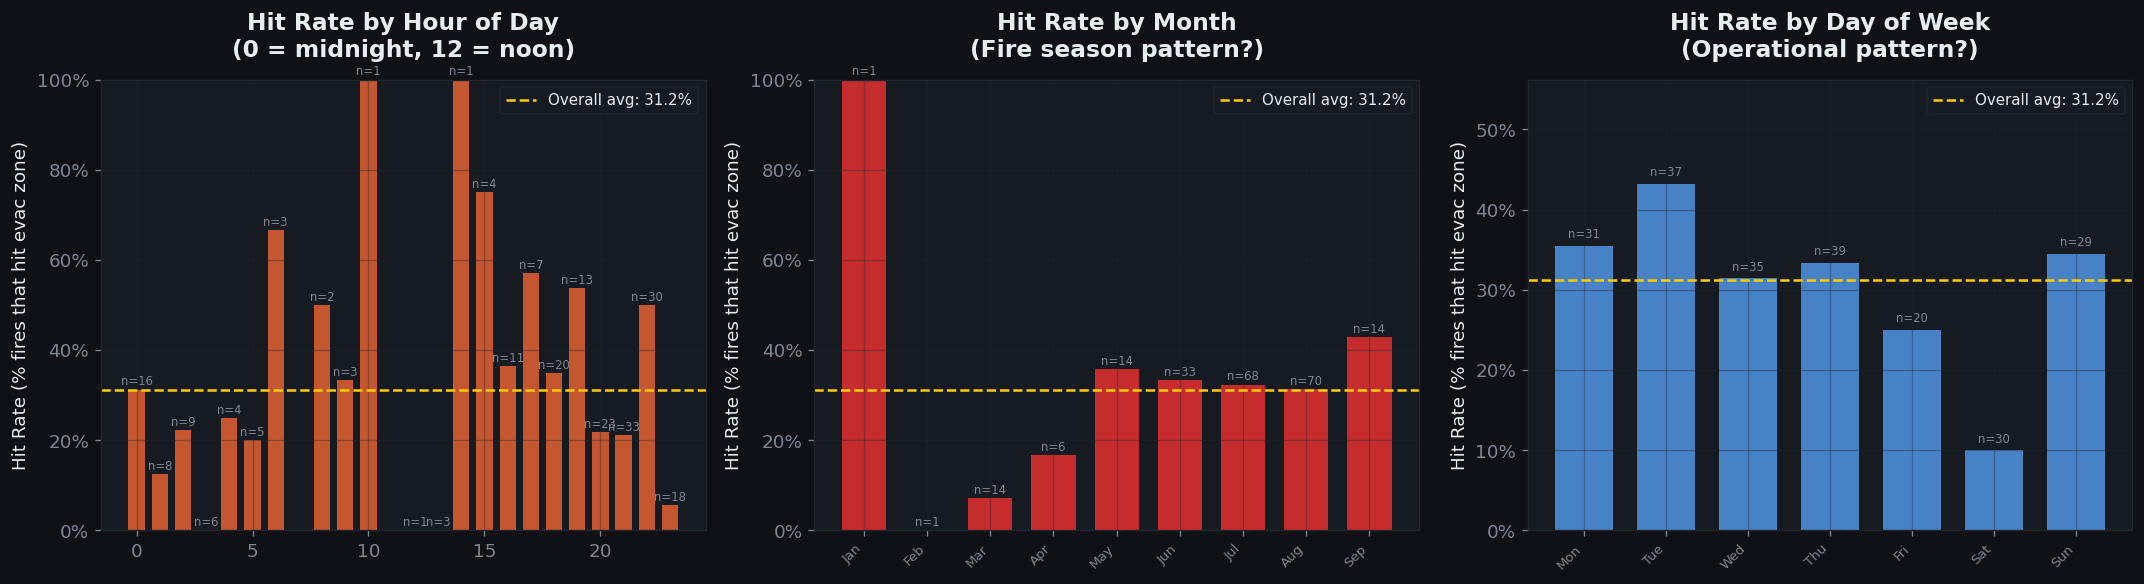

Chi-squared test: temporal feature có liên quan đến hit/miss không?
(p < 0.05 = có sự khác biệt có ý nghĩa thống kê)

  Hour of day         : chi2=35.12, p=0.0274  →  ✅ Significant
  Month               : chi2=8.15, p=0.4186  →  ❌ Not significant
  Day of week         : chi2=9.63, p=0.1411  →  ❌ Not significant


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Helper: plot hit rate by categorical feature ──────────────────────────────
def plot_temporal(ax, col, title, x_labels=None, color_main=HIT_COLOR):
    grp = train_raw.groupby(col)['event'].agg(['mean', 'count']).reset_index()
    grp.columns = [col, 'hit_rate', 'count']

    bars = ax.bar(
        grp[col], grp['hit_rate'],
        color=color_main, alpha=0.75, edgecolor='none', width=0.7
    )

    # Count annotations
    for bar, cnt in zip(bars, grp['count']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'n={cnt}', ha='center', fontsize=7, color=MUTED_COLOR
        )

    # Overall hit rate reference line
    overall = train_raw['event'].mean()
    ax.axhline(overall, color=FIRE_COLORS[2], ls='--', lw=1.5,
               label=f'Overall avg: {overall:.1%}')

    if x_labels:
        ax.set_xticks(grp[col])
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)

    ax.set_ylim(0, min(1.0, grp['hit_rate'].max() * 1.3))
    ax.set_title(title)
    ax.set_ylabel('Hit Rate (% fires that hit evac zone)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.legend(fontsize=9)

# ── Chart 1: Hit rate by hour of day ─────────────────────────────────────────
plot_temporal(axes[0], 'event_start_hour',
              'Hit Rate by Hour of Day\n(0 = midnight, 12 = noon)',
              color_main=FIRE_COLORS[0])

# ── Chart 2: Hit rate by month ────────────────────────────────────────────────
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# Thay vì truyền month_names cứng, map đúng theo tháng có trong data
grp_month = train_raw.groupby('event_start_month')['event'].agg(['mean', 'count']).reset_index()
grp_month.columns = ['event_start_month', 'hit_rate', 'count']

# Lấy labels đúng theo tháng thực có trong data (không phải 12 tháng cứng)
actual_month_labels = [month_names[m - 1] for m in grp_month['event_start_month']]

plot_temporal(axes[1], 'event_start_month',
              'Hit Rate by Month\n(Fire season pattern?)',
              x_labels=actual_month_labels,   # ← fix: labels khớp với tháng thực có
              color_main=FIRE_COLORS[1])

# ── Chart 3: Hit rate by day of week ─────────────────────────────────────────
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
plot_temporal(axes[2], 'event_start_dayofweek',
              'Hit Rate by Day of Week\n(Operational pattern?)',
              x_labels=day_names,
              color_main=MISS_COLOR)

plt.tight_layout()
plt.show()

# Chi-squared test for each temporal feature
from scipy.stats import chi2_contingency

print("Chi-squared test: temporal feature có liên quan đến hit/miss không?")
print("(p < 0.05 = có sự khác biệt có ý nghĩa thống kê)")
print()
for col, name in [('event_start_hour', 'Hour of day'),
                   ('event_start_month', 'Month'),
                   ('event_start_dayofweek', 'Day of week')]:
    ct = pd.crosstab(train_raw[col], train_raw['event'])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = '✅ Significant' if p < 0.05 else '❌ Not significant'
    print(f"  {name:20s}: chi2={chi2:.2f}, p={p:.4f}  →  {sig}")

---
**5. Low Temporal Resolution Flag Analysis**

*`low_temporal_resolution_0_5h` là gì?*: Flag = 1 khi đám cháy chỉ có **1 perimeter observation** hoặc khoảng thời gian giữa các observations **< 0.5 giờ** trong 5 giờ đầu. Nói đơn giản: data chất lượng kém.

Điều này quan trọng vì:
1. Nhiều features khác (growth rate, closing speed, ...) được tính từ multiple observations → nếu chỉ có 1 observation, các features này có thể là **0, NaN, hoặc nhiễu**
2. Model có thể học sai patterns từ các fires này
3. Nếu fires low-res có hit rate khác hẳn → flag này trở thành feature quan trọng
4. Có thể cần xử lý riêng (impute khác, train riêng, hoặc loại bỏ)

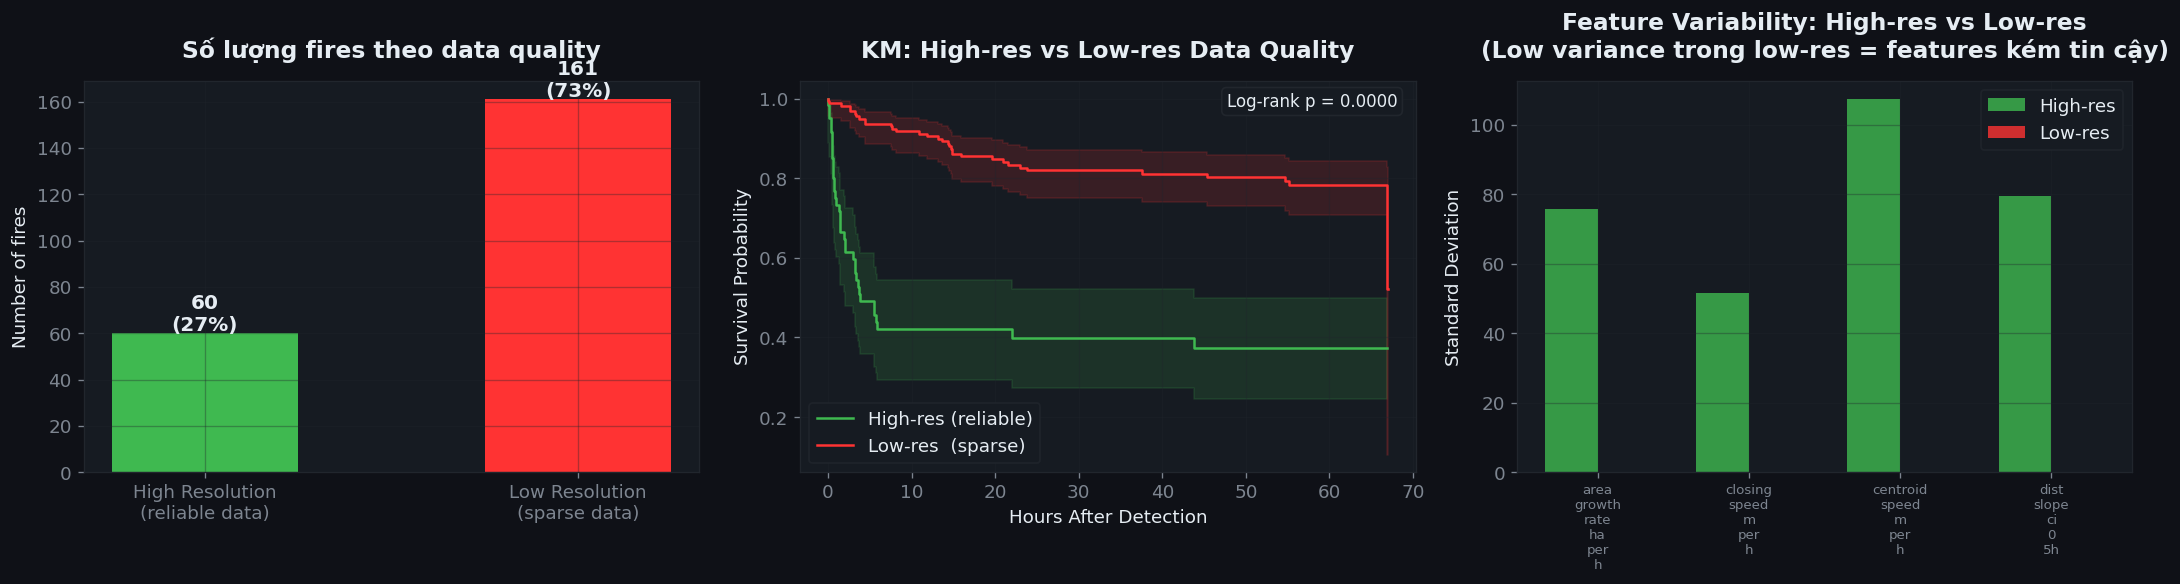

Tóm tắt Low Temporal Resolution:
  High-res fires: 60 (27%) — hit rate: 60.0%
  Low-res fires:  161  (73%) — hit rate: 20.5%

⚠️  Hit rate khác biệt rõ → low_temporal_resolution_0_5h là feature quan trọng!
   Nên keep flag này trong model và có thể xem xét imputation strategy riêng.


In [ ]:
low_res  = train_raw[train_raw['low_temporal_resolution_0_5h'] == 1]
high_res = train_raw[train_raw['low_temporal_resolution_0_5h'] == 0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Chart 1: How many fires are low-res? ─────────────────────────────────────
n_low  = len(low_res)
n_high = len(high_res)
bars = axes[0].bar(
    ['High Resolution\n(reliable data)', 'Low Resolution\n(sparse data)'],
    [n_high, n_low],
    color=[SAFE_COLOR, FIRE_COLORS[1]],
    edgecolor='none', width=0.5
)
for bar, cnt in zip(bars, [n_high, n_low]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{cnt}\n({cnt/len(train_raw):.0%})',
        ha='center', fontweight='bold', fontsize=12, color=TEXT_COLOR
    )
axes[0].set_title('Số lượng fires theo data quality')
axes[0].set_ylabel('Number of fires')

# ── Chart 2: KM curves — low-res vs high-res ─────────────────────────────────
for subset, label, color in [
    (high_res, 'High-res (reliable)', SAFE_COLOR),
    (low_res,  'Low-res  (sparse)',   FIRE_COLORS[1]),
]:
    if len(subset) > 0:
        kmf = KaplanMeierFitter()
        kmf.fit(subset['time_to_hit_hours'], event_observed=subset['event'], label=label)
        kmf.plot_survival_function(ax=axes[1], color=color, ci_show=True, ci_alpha=0.15)

if len(low_res) > 0 and len(high_res) > 0:
    lr = logrank_test(
        high_res['time_to_hit_hours'], low_res['time_to_hit_hours'],
        event_observed_A=high_res['event'], event_observed_B=low_res['event']
    )
    axes[1].text(
        0.97, 0.97, f'Log-rank p = {lr.p_value:.4f}',
        transform=axes[1].transAxes, ha='right', va='top',
        fontsize=10, color=TEXT_COLOR,
        bbox=dict(boxstyle='round,pad=0.3', facecolor=CARD_BG, edgecolor=GRID_COLOR)
    )

axes[1].set_title('KM: High-res vs Low-res Data Quality')
axes[1].set_xlabel('Hours After Detection')
axes[1].set_ylabel('Survival Probability')

# ── Chart 3: Feature quality — how much does low_res affect other features? ──
# Check variance of key features in low vs high res groups
affected_features = [
    'area_growth_rate_ha_per_h', 'closing_speed_m_per_h',
    'centroid_speed_m_per_h', 'dist_slope_ci_0_5h'
]
available_affected = [f for f in affected_features if f in train_raw.columns]

if available_affected:
    std_high = high_res[available_affected].std()
    std_low  = low_res[available_affected].std() if len(low_res) > 1 else pd.Series(0, index=available_affected)

    x = np.arange(len(available_affected))
    w = 0.35
    axes[2].bar(x - w/2, std_high.values, w, label='High-res', color=SAFE_COLOR,   alpha=0.8, edgecolor='none')
    axes[2].bar(x + w/2, std_low.values,  w, label='Low-res',  color=FIRE_COLORS[1], alpha=0.8, edgecolor='none')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels([f.replace('_', '\n') for f in available_affected], fontsize=8)
    axes[2].set_title('Feature Variability: High-res vs Low-res\n(Low variance trong low-res = features kém tin cậy)')
    axes[2].set_ylabel('Standard Deviation')
    axes[2].legend()

plt.tight_layout()
plt.show()

# Summary statistics
print("Tóm tắt Low Temporal Resolution:")
print(f"  High-res fires: {n_high} ({n_high/len(train_raw):.0%}) — hit rate: {high_res['event'].mean():.1%}")
print(f"  Low-res fires:  {n_low}  ({n_low/len(train_raw):.0%}) — hit rate: {low_res['event'].mean():.1%}")
print()
if abs(high_res['event'].mean() - low_res['event'].mean()) > 0.05:
    print("⚠️  Hit rate khác biệt rõ → low_temporal_resolution_0_5h là feature quan trọng!")
    print("   Nên keep flag này trong model và có thể xem xét imputation strategy riêng.")
else:
    print("✅  Hit rate tương tự → flag ít ảnh hưởng đến outcome, nhưng vẫn nên monitor.")

---
**6. EDA Summary — Tổng kết các findings**

Cell cuối này tổng hợp tất cả insights quan trọng từ EDA để định hướng modeling.

In [ ]:
from scipy.stats import chi2_contingency

# ── Collect all key numbers ───────────────────────────────────────────────────
n_total    = len(train_raw)
n_hits     = int(train_raw['event'].sum())
n_censored = n_total - n_hits
hit_rate   = n_hits / n_total
censor_rate = n_censored / n_total

hit_times = train_raw.loc[train_raw['event'] == 1, 'time_to_hit_hours']

# KM survival probabilities
kmf_summary = KaplanMeierFitter()
kmf_summary.fit(train_raw['time_to_hit_hours'], event_observed=train_raw['event'])
sf_at = {h: kmf_summary.survival_function_at_times(h).values[0] for h in [12, 24, 48, 72]}

# Top feature from Cox
top1_feat = cox_df.iloc[0]['feature']
top1_hr   = cox_df.iloc[0]['hazard_ratio']
top1_p    = cox_df.iloc[0]['p_value']
n_sig_features = cox_df['significant'].sum()

# Low-res stats
n_lowres  = int(train_raw['low_temporal_resolution_0_5h'].sum())

# ── Print summary ─────────────────────────────────────────────────────────────
print("=" * 65)
print("EDA SUMMARY — WiDS 2026 Wildfire Survival Analysis")
print("=" * 65)

print("\n📦 DATASET")
print(f"   {n_total} fires total  |  {n_hits} hits ({hit_rate:.1%})  |  {n_censored} censored ({censor_rate:.1%})")
print(f"   → Censor rate {censor_rate:.0%}: khá cao, PHẢI dùng survival methods")
print(f"     (nếu dùng classification thông thường sẽ bị bias nặng)")

print("\n⏱️  TIMING (fires that hit)")
print(f"   Median time-to-hit : {hit_times.median():.1f} hours")
print(f"   75th percentile    : {hit_times.quantile(0.75):.1f} hours")
print(f"   Fastest fire       : {hit_times.min():.1f} hours")

print("\n📉 SURVIVAL PROBABILITIES (Kaplan-Meier)")
for h, sf in sf_at.items():
    print(f"   By {h:2d}h: {1-sf:.1%} of fires have hit  |  {sf:.1%} still safe")

print("\n🔬 FEATURE IMPORTANCE (Cox Univariate)")
print(f"   {n_sig_features} / {len(cox_df)} features significant (p < 0.05)")
print(f"   Top feature: {top1_feat}")
print(f"     HR = {top1_hr:.3f}, p = {top1_p:.4f}")
if top1_hr > 1:
    print(f"     → Mỗi 1 SD tăng làm tăng hazard {(top1_hr-1)*100:.0f}%")
else:
    print(f"     → Mỗi 1 SD tăng làm giảm hazard {(1-top1_hr)*100:.0f}%")

print("\n🗓️  TEMPORAL FEATURES")
for col, name in [('event_start_hour','Hour'), ('event_start_month','Month'), ('event_start_dayofweek','Day of week')]:
    ct = pd.crosstab(train_raw[col], train_raw['event'])
    _, p, _, _ = chi2_contingency(ct)
    status = '✅ Keep' if p < 0.05 else '⚪ Weak'
    print(f"   {name:15s}: p={p:.4f}  {status}")

print("\n⚠️  DATA QUALITY")
print(f"   Low-res fires: {n_lowres} ({n_lowres/n_total:.0%}) — features kém tin cậy")
hr_hi = high_res['event'].mean()
hr_lo = low_res['event'].mean()
print(f"   Hit rate — High-res: {hr_hi:.1%}  |  Low-res: {hr_lo:.1%}")

print("\n🎯 MODELING RECOMMENDATIONS")
print("   1. Dùng Cox PH hoặc survival forest (không phải logistic regression)")
print("   2. Evaluate bằng C-index + Brier Score, KHÔNG dùng AUC đơn thuần")
print("   3. Đặc biệt chú ý calibration tại 24h, 48h, 72h (70% của score)")
print("   4. Xem xét interaction features: distance × closing_speed")
print("   5. Xử lý riêng nhóm low_temporal_resolution nếu hit rate khác biệt")
print("=" * 65)

EDA SUMMARY — WiDS 2026 Wildfire Survival Analysis

📦 DATASET
   221 fires total  |  69 hits (31.2%)  |  152 censored (68.8%)
   → Censor rate 69%: khá cao, PHẢI dùng survival methods
     (nếu dùng classification thông thường sẽ bị bias nặng)

⏱️  TIMING (fires that hit)
   Median time-to-hit : 3.5 hours
   75th percentile    : 14.3 hours
   Fastest fire       : 0.0 hours

📉 SURVIVAL PROBABILITIES (Kaplan-Meier)
   By 12h: 22.5% of fires have hit  |  77.5% still safe
   By 24h: 29.4% of fires have hit  |  70.6% still safe
   By 48h: 31.3% of fires have hit  |  68.7% still safe
   By 72h: 55.2% of fires have hit  |  44.8% still safe

🔬 FEATURE IMPORTANCE (Cox Univariate)
   26 / 32 features significant (p < 0.05)
   Top feature: closing_speed_abs_m_per_h
     HR = 10.090, p = 0.0000
     → Mỗi 1 SD tăng làm tăng hazard 909%

🗓️  TEMPORAL FEATURES
   Hour           : p=0.0274  ✅ Keep
   Month          : p=0.4186  ⚪ Weak
   Day of week    : p=0.1411  ⚪ Weak

⚠️  DATA QUALITY
   Low-res f